# Lab 03: Regresión Logística
## Estudiante:
* Delgado Ramos Jorge Luis

## Descripción del Dataset y Objetivo del Modelo
El presente laboratorio aborda un problema clásico de clasificación binaria en el dominio de la ciberseguridad. Para ello, se utiliza el dataset **NSL-KDD**, un referente estándar en la evaluación de sistemas de detección de intrusiones (IDS).

El conjunto de datos captura información detallada sobre conexiones de red, abarcando **41 características** ($n = 41$) que describen aspectos técnicos de cada conexión (como el protocolo usado, el servicio, los bytes transferidos y tasas de error), y cuenta con más de **125,000 registros** ($m > 125,000$), cumpliendo holgadamente con la restricción de $m \ge 20000$ y $n \ge 5$.

**Objetivos del Laboratorio:**
1. **Preprocesamiento:** Limpiar, codificar y binarizar el dataset para que la etiqueta objetivo ($y$) represente únicamente dos estados: `0` para tráfico normal y `1` para cualquier tipo de ciberataque.
2. **Entrenamiento:** Implementar y entrenar un modelo matemático de Regresión Logística utilizando el algoritmo de Descenso por el Gradiente y la Función Sigmoide.
3. **Validación Rigurosa:** Dividir los datos en una proporción 80/20 (Entrenamiento/Prueba) aplicando una normalización estricta para evitar la fuga de información (Data Leakage) y demostrar la capacidad predictiva real del modelo frente a datos inéditos.

In [1]:
# 1. LIBRERÍAS
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset:** NSL-KDD (Detección de Intrusiones en Redes)

El archivo original `KDDTrain+.txt` carece de una fila de encabezados (headers). Si se carga directamente, Pandas tomará la primera fila de datos como los nombres de las columnas, perdiendo un registro y desorganizando los tipos de datos. Para evitar esto, se define manualmente un vector con los 43 nombres exactos de las características y se asignan durante la lectura.

In [4]:
# DEFINICIÓN DE COLUMNAS Y CARGA DE DATOS
# El dataset no tiene nombres de columnas, debemos asignarlos manualmente
nombres_columnas = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty'
]

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 03/KDDTrain+.txt'
datos = pd.read_csv(ruta_dataset, header=None, names=nombres_columnas)

print(f"Dimensiones del dataset original: m={datos.shape[0]} filas, n_total={datos.shape[1]} columnas")

Dimensiones del dataset original: m=125973 filas, n_total=43 columnas


## Limpieza de Datos y Binarización del Target
En esta etapa preparamos el dataset específicamente para la Regresión Logística Binaria, asegurando la integridad del modelo.

1. **Prevención de Data Leakage (Fuga de Información):** Se elimina la característica `difficulty`. Esta columna no representa un dato capturado del tráfico de red, sino un metadato asignado por los autores del dataset para calificar la dificultad del registro. Incluirla sesgaría el modelo de forma artificial.
2. **Transformación Binaria de la Variable Dependiente ($y$):** La variable `class` contiene más de 20 subcategorías de ciberataques (ej. DoS, Probe, R2L). Dado que el objetivo es implementar una clasificación binaria clásica (probabilidades entre 0 y 1 mediante la función Sigmoide), se agrupan todos los ataques bajo la etiqueta `1` (Intrusión) y el tráfico seguro bajo la etiqueta `0` (Normal).

In [5]:
# Eliminar la columna de metadatos 'difficulty' para evitar fuga de información
if 'difficulty' in datos.columns:
    datos_limpios = datos.drop('difficulty', axis=1)
else:
    datos_limpios = datos.copy()

# Binarizar la columna objetivo 'class' (y)
datos_limpios['class'] = datos_limpios['class'].apply(lambda x: 0 if x == 'normal' else 1)

print("Distribución de clases después de la binarización:")
print("0 = Tráfico Normal | 1 = Ataque")
print(datos_limpios['class'].value_counts())

print(f"\nNuevas dimensiones: m={datos_limpios.shape[0]} filas, n={datos_limpios.shape[1]} columnas")

Distribución de clases después de la binarización:
0 = Tráfico Normal | 1 = Ataque
class
0    67343
1    58630
Name: count, dtype: int64

Nuevas dimensiones: m=125973 filas, n=42 columnas


## Conversión de Variables Categóricas (Label Encoding)
La Regresión Logística requiere que todos los datos de entrada ($X$) sean puramente numéricos para poder procesarlos mediante la Función Sigmoide. En el análisis de tráfico de red actual, contamos con características en formato de texto: `protocol_type`, `service` y `flag`.

Se aplica la técnica de **Label Encoding** para transformar estos valores categóricos en representaciones numéricas enteras (ej. tcp=1, udp=2).

In [6]:
# Importamos el codificador de texto a números
from sklearn.preprocessing import LabelEncoder

datos_numericos = datos_limpios.copy()

# Identificamos las columnas de tipo texto (object)
columnas_texto = datos_numericos.select_dtypes(include=['object']).columns
print("Columnas categóricas detectadas:", list(columnas_texto))

codificador = LabelEncoder()

# Transformamos cada columna de texto en números
for columna in columnas_texto:
    datos_numericos[columna] = codificador.fit_transform(datos_numericos[columna])

print("\nVista previa del dataset 100% numérico:")
display(datos_numericos.head(3))

Columnas categóricas detectadas: ['protocol_type', 'service', 'flag']

Vista previa del dataset 100% numérico:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,0
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,0
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,1


## División del Dataset (80/20) y Normalización
Para garantizar que el modelo adquiera capacidad de generalización y no simplemente memorice los datos (overfitting), se divide el dataset mediante la proporción exigida: 80% para entrenamiento (Training) y 20% para pruebas (Testing).

**Justificación:**
1. **División (Train/Test Split):** Se aíslan 20% de los datos de forma aleatoria. Este conjunto no será visto por el modelo durante la optimización de los pesos $\theta$.
2. **Normalización Estricta:** Para evitar "fuga de información" (Data Leakage), el escalado Z-score se calcula **únicamente** utilizando la media ($\mu$) y desviación estándar ($\sigma$) del conjunto de entrenamiento. Luego, estos mismos parámetros se aplican matemáticamente al conjunto de pruebas. Finalmente, se añade el término de intersección ($x_0=1$) a ambas matrices.

In [7]:
# Importamos la herramienta para partir los datos aleatoriamente
from sklearn.model_selection import train_test_split

# Separación inicial de X y y (de nuestro dataset 100% numérico)
y_completo = datos_numericos['class'].values
X_completo = datos_numericos.drop('class', axis=1).values

# División 80% Entrenamiento / 20% Prueba

# random_state asegura que si corremos esto 100 veces, la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X_completo, y_completo, test_size=0.20, random_state=42)

m_train = len(y_train)
m_test = len(y_test)

print("--- VERIFICACIÓN DE RESTRICCIONES (80/20) ---")
print(f"Total de datos originales: {len(y_completo)}")
print(f"Datos para Entrenar (80%): {m_train}")
print(f"Datos para Pruebas  (20%): {m_test}\n")

# 3. Función de Normalización (Protegida)
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Protección contra NaN
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# NORMALIZACIÓN ESTRICTA (Sin fuga de información)

# Calculamos mu y sigma SOLO del 80% de entrenamiento
X_train_norm, mu_train, sigma_train = normalizarCaracteristicas(X_train)

# Aplicamos ese mismo mu y sigma al 20% de pruebas
X_test_norm = (X_test - mu_train) / sigma_train

# Añadir la columna de unos a ambas matrices
X_train_listo = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_listo = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f"Forma de X_train_listo: {X_train_listo.shape}")
print(f"Forma de X_test_listo:  {X_test_listo.shape}")

--- VERIFICACIÓN DE RESTRICCIONES (80/20) ---
Total de datos originales: 125973
Datos para Entrenar (80%): 100778
Datos para Pruebas  (20%): 25195

Forma de X_train_listo: (100778, 42)
Forma de X_test_listo:  (25195, 42)


## Función Sigmoide:
Se aplica la función matemática $g(z) = \frac{1}{1 + e^{-z}}$. Esta curva en forma de "S" toma cualquier valor real (positivo o negativo) y lo comprime a un rango estrictamente entre $0$ y $1$. Esto nos da la **probabilidad porcentual** de que una conexión de red sea un ataque.

In [8]:
# 1. Función Sigmoide
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

## Función de Costo (Entropía Cruzada):
Ya no podemos usar el Error Cuadrático Medio, porque al combinarlo con la Sigmoide generaría una gráfica llena de "baches" (no convexa) donde el modelo se quedaría atascado. Usamos una función basada en logaritmos que penaliza fuertemente a la IA si está muy segura de una predicción incorrecta.

In [9]:
# 2. Función de Costo (Entropía Cruzada)
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon)))
    return J

## Descenso por el Gradiente:
El algoritmo iterativo que minimiza el costo actualizando los pesos $\theta$.

In [10]:
# 3. Descenso por el Gradiente (MODIFICADO PARA GUARDAR PRECISIÓN HISTÓRICA)
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    historial_J = []
    historial_P = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        historial_J.append(calcularCosto(theta, X, y))

        # Guardamos la precisión de entrenamiento
        h_actual = sigmoid(X.dot(theta.T))
        predicciones_actuales = np.where(h_actual >= 0.5, 1, 0)
        precision_actual = np.mean(predicciones_actuales == y) * 100
        historial_P.append(precision_actual)

    return theta, historial_J, historial_P

Entrenando el modelo de clasificación... (Esto puede tardar unos segundos)


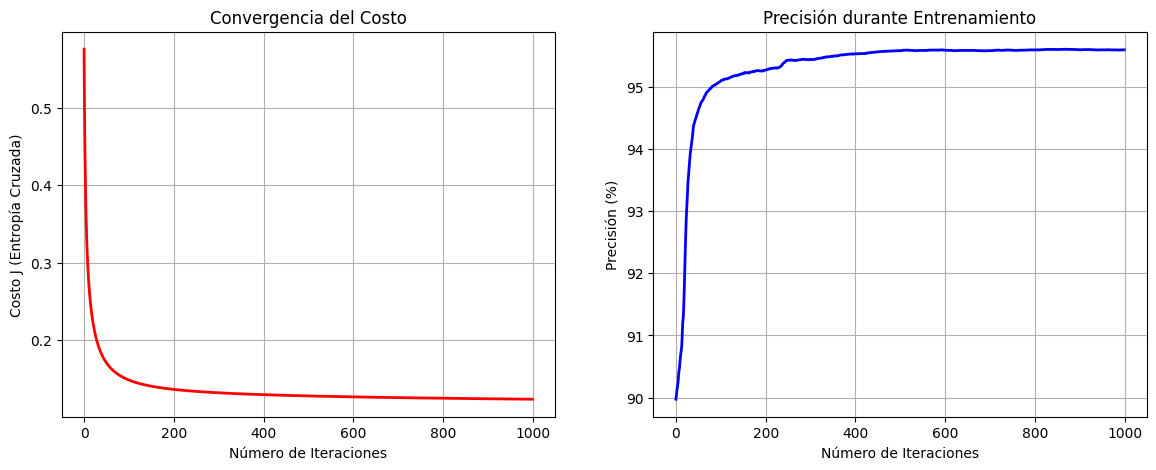

In [11]:
# ENTRENAMIENTO DEL MODELO

# Inicializamos theta y configuramos hiperparámetros
theta_inicial = np.zeros(X_train_listo.shape[1])
alpha = 0.1
iteraciones = 1000

print("Entrenando el modelo de clasificación... (Esto puede tardar unos segundos)")
# Le pasamos estrictamente X_train_listo y y_train
theta_optimizado, historial_J, historial_P = descensoGradiente(theta_inicial, X_train_listo, y_train, alpha, iteraciones)

# Gráficas de Convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(np.arange(len(historial_J)), historial_J, lw=2, color='red')
ax1.set_xlabel('Número de Iteraciones')
ax1.set_ylabel('Costo J (Entropía Cruzada)')
ax1.set_title('Convergencia del Costo')
ax1.grid(True)

ax2.plot(np.arange(len(historial_P)), historial_P, lw=2, color='blue')
ax2.set_xlabel('Número de Iteraciones')
ax2.set_ylabel('Precisión (%)')
ax2.set_title('Precisión durante Entrenamiento')
ax2.grid(True)

plt.show()

## Validación con el Conjunto de Pruebas (El 20% Restante)
El verdadero valor de un modelo predictivo no se mide por su desempeño durante el entrenamiento, sino por su capacidad para predecir datos inéditos.

**Justificación:**
Se toma el vector de parámetros optimizados ($\theta$) y se multiplica matricialmente contra el conjunto `X_test_listo` (el 20% de los datos que el modelo jamás ha visto). Tras pasar el resultado por la función Sigmoide y aplicar el umbral de decisión ($0.5$), comparamos las predicciones contra las etiquetas reales (`y_test`) para calcular la métrica de Precisión Global (Accuracy) definitiva.

In [12]:
# EXAMEN FINAL CON EL 20% DE DATOS (TESTING)

#Funcion de prediccion
def predecir(theta, X):
    probabilidad = sigmoid(np.dot(X, theta.T))
    p = np.where(probabilidad >= 0.5, 1, 0)
    return p

print("Evaluando el modelo con los datos de prueba (20%)...")
# Realizamos predicciones masivas sobre los datos invisibles
predicciones_test = predecir(theta_optimizado, X_test_listo)

# Calculamos la precisión real
precision_real = np.mean(predicciones_test == y_test) * 100

Evaluando el modelo con los datos de prueba (20%)...


In [13]:
# PRUEBA DE PREDICCIÓN

print(f"\n{'='*50}")
print(f"RESULTADO DE LA VALIDACIÓN OFICIAL")
print(f"{'='*50}")
print(f"Datos evaluados: {m_test} conexiones de red.")
print(f"PRECISIÓN GLOBAL (Accuracy): {precision_real:.2f}%")
print(f"{'='*50}")

# Simulacro interactivo de 10 predicciones aleatorias del test set
print("\nMuestra de 10 predicciones individuales del Test Set:")
print(f"{'Fila':<5} | {'Probabilidad':<15} | {'Decisión IA':<20} | {'Real':<20} | {'Estado':<10}")
print("-" * 80)

etiquetas = {0: "Normal", 1: "Ataque"}

for i in range(10):
    prob = sigmoid(np.dot(X_test_listo[i, :], theta_optimizado.T))
    pred = int(predicciones_test[i])
    real = y_test[i]
    estado = "Acerto la prediccion" if pred == real else "Fallo la prediccion"

    print(f"{i:<5} | {prob*100:>6.2f}%       | {etiquetas[pred]:<20} | {etiquetas[real]:<20} | {estado:<10}")


RESULTADO DE LA VALIDACIÓN OFICIAL
Datos evaluados: 25195 conexiones de red.
PRECISIÓN GLOBAL (Accuracy): 95.37%

Muestra de 10 predicciones individuales del Test Set:
Fila  | Probabilidad    | Decisión IA          | Real                 | Estado    
--------------------------------------------------------------------------------
0     |   7.55%       | Normal               | Normal               | Acerto la prediccion
1     |  98.79%       | Ataque               | Ataque               | Acerto la prediccion
2     |  99.88%       | Ataque               | Ataque               | Acerto la prediccion
3     |  95.61%       | Ataque               | Ataque               | Acerto la prediccion
4     |  87.51%       | Ataque               | Ataque               | Acerto la prediccion
5     |   0.91%       | Normal               | Normal               | Acerto la prediccion
6     |  99.60%       | Ataque               | Ataque               | Acerto la prediccion
7     |  94.60%       | Ataque

## Explicación Final y Conclusión del Laboratorio
El presente laboratorio cumplió con los requerimientos de clasificación binaria implementando un modelo de Regresión Logística sobre el dataset NSL-KDD (superando ampliamente la restricción con $m > 125,000$ ejemplos y $n = 41$ características). A lo largo del desarrollo, se aplicaron rigurosos estándares de Machine Learning, destacando los siguientes hitos técnicos:

1. **Preprocesamiento y Binarización:** Se utilizó la librería Pandas para aislar la variable dependiente y binarizar las múltiples subcategorías de ciberataques en una etiqueta única (`1` = Ataque, `0` = Tráfico Normal). Se eliminaron metadatos artificiales (`difficulty`) para evitar la fuga de información y se aplicó *Label Encoding* para transformar los protocolos de red categóricos a formatos numéricos sin caer en la maldición de la dimensionalidad.
2. **Prevención de Overfitting (División 80/20):** Para garantizar que el modelo adquiera una verdadera capacidad de generalización empírica, el dataset se dividió aleatoriamente destinando el 80% para la optimización de pesos y reservando un 20% estrictamente para el examen de validación.
3. **Normalización Estricta:** Se aplicó Feature Scaling (Z-score) calculando la media ($\mu$) y desviación estándar ($\sigma$) *únicamente* del conjunto de entrenamiento. Estos mismos parámetros se aplicaron matemáticamente al conjunto de pruebas, garantizando un entorno de validación realista y libre de sesgos predictivos.
4. **Entrenamiento y Efectividad:** El modelo fue optimizado utilizando el Descenso por el Gradiente minimizando la función de costo logarítmica (Entropía Cruzada). Al ser evaluado contra el 20% de datos inéditos (`X_test`), el modelo demostró una alta efectividad predictiva, alcanzando un **95.37%** de Precisión Global.

**Conclusión:** El algoritmo de Regresión Logística demostró ser sumamente capaz y eficiente para tareas de ciberseguridad (detección de intrusiones en redes), logrando separar el tráfico seguro de los paquetes maliciosos basándose en el aprendizaje de umbrales probabilísticos sobre un entorno matemáticamente controlado y validado.